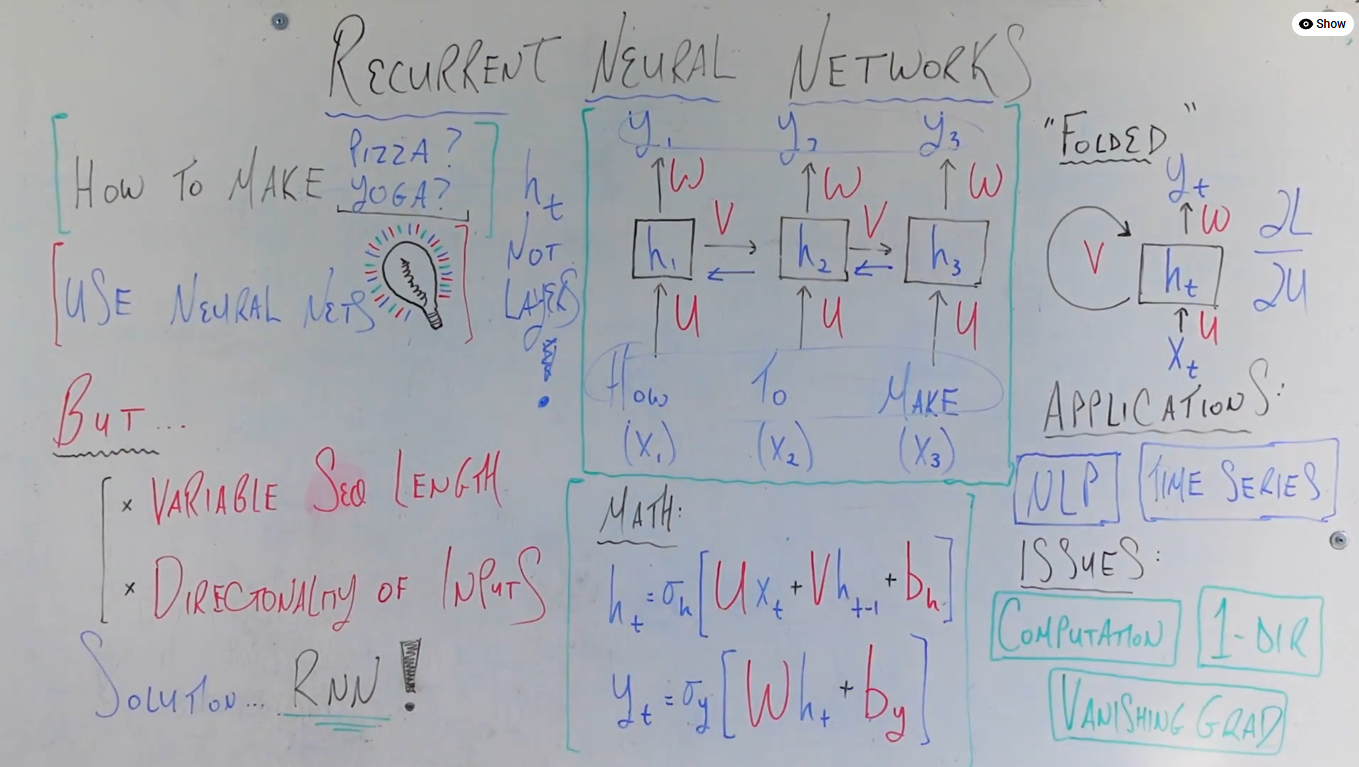

In [4]:
%pip install datasets

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached typer_slim-0.24.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached charset_normalizer-3.4.4-cp314-cp314-win_amd64.whl.metadata (38 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using 

In [1]:
print("hello")

hello


In [2]:
from datasets import load_dataset
dataset = load_dataset("roneneldan/TinyStories")
train_texts = dataset["train"]["text"]

c:\Users\ELCOT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ELCOT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ELCOT\.cache\huggingface\hub\datasets--roneneldan--TinyStories. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an

Word level tokenisation + vocab building

In [3]:
from collections import Counter

def tokenize(text):
    return text.lower().split()

all_words = []

for text in train_texts[:50000]:  
    all_words.extend(tokenize(text))

vocab = Counter(all_words)
vocab = {word:i+1 for i,(word,_) in enumerate(vocab.items())}
vocab["<unk>"] = 0

inv_vocab = {i:w for w,i in vocab.items()}
vocab_size = len(vocab)

print("Vocab size:", vocab_size)

Vocab size: 53411


In [4]:
def encode(text):
    return [vocab.get(w, 0) for w in tokenize(text)]

In [5]:
seq_len = 20

In [6]:
import torch

sequences = []

for text in train_texts[:50000]:
    tokens = encode(text)

    for i in range(len(tokens) - seq_len):
        seq = tokens[i:i+seq_len+1]
        sequences.append(seq)

sequences = torch.tensor(sequences)

In [7]:
X = sequences[:, :-1]
y = sequences[:, 1:]

In [8]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [9]:
import torch.nn as nn

class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

In [10]:
model = RNNLanguageModel(vocab_size)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch
        y_batch = y_batch

        optimizer.zero_grad()

        output, _ = model(x_batch)

        loss = criterion(
            output.reshape(-1, vocab_size),
            y_batch.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch, "Loss:", total_loss/len(loader))

KeyboardInterrupt: 